<a href="https://colab.research.google.com/github/ConsularParadi/Practice/blob/main/stanford_dogs_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES
# TO THE CORRECT LOCATION (/kaggle/input) IN YOUR NOTEBOOK,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.

import os
import sys
from tempfile import NamedTemporaryFile
from urllib.request import urlopen
from urllib.parse import unquote, urlparse
from urllib.error import HTTPError
from zipfile import ZipFile
import tarfile
import shutil

CHUNK_SIZE = 40960
DATA_SOURCE_MAPPING = 'stanford-dogs-dataset:https%3A%2F%2Fstorage.googleapis.com%2Fkaggle-data-sets%2F119698%2F791828%2Fbundle%2Farchive.zip%3FX-Goog-Algorithm%3DGOOG4-RSA-SHA256%26X-Goog-Credential%3Dgcp-kaggle-com%2540kaggle-161607.iam.gserviceaccount.com%252F20240225%252Fauto%252Fstorage%252Fgoog4_request%26X-Goog-Date%3D20240225T110254Z%26X-Goog-Expires%3D259200%26X-Goog-SignedHeaders%3Dhost%26X-Goog-Signature%3D37ce60c585f3118294d04cfcd863c6505d37d36514432b902390456f7e650b6cf521088a44945a8056f212e2b9032b413ec3cde0693007264136f2acf88ad088b02e368afb0e26f997102d362a86777df8bdc0aa7146522e4b22b1f49b4df8aaceec3579d0491c8cb0249ee320c7e41dd3257dfc1f33593bdd02ea1d46258d09112503a4c8581a6bd3ff2ae9909f7adab98d5a81e96fe5c5e2f8bab7a1a371964a48f4cd8b0a70c6978d24888ff7050ab4aef541d456a186063616220b23ba8b34103df785e9d48f1fd78e4ca28f0c90747a866d69c1fbf6b8c32c4133e22898689f039b0310113114b597cbf5b8e9ce33bc0eb6d9b305e5fd8d97d9e1294fc7'

KAGGLE_INPUT_PATH='/kaggle/input'
KAGGLE_WORKING_PATH='/kaggle/working'
KAGGLE_SYMLINK='kaggle'

!umount /kaggle/input/ 2> /dev/null
shutil.rmtree('/kaggle/input', ignore_errors=True)
os.makedirs(KAGGLE_INPUT_PATH, 0o777, exist_ok=True)
os.makedirs(KAGGLE_WORKING_PATH, 0o777, exist_ok=True)

try:
  os.symlink(KAGGLE_INPUT_PATH, os.path.join("..", 'input'), target_is_directory=True)
except FileExistsError:
  pass
try:
  os.symlink(KAGGLE_WORKING_PATH, os.path.join("..", 'working'), target_is_directory=True)
except FileExistsError:
  pass

for data_source_mapping in DATA_SOURCE_MAPPING.split(','):
    directory, download_url_encoded = data_source_mapping.split(':')
    download_url = unquote(download_url_encoded)
    filename = urlparse(download_url).path
    destination_path = os.path.join(KAGGLE_INPUT_PATH, directory)
    try:
        with urlopen(download_url) as fileres, NamedTemporaryFile() as tfile:
            total_length = fileres.headers['content-length']
            print(f'Downloading {directory}, {total_length} bytes compressed')
            dl = 0
            data = fileres.read(CHUNK_SIZE)
            while len(data) > 0:
                dl += len(data)
                tfile.write(data)
                done = int(50 * dl / int(total_length))
                sys.stdout.write(f"\r[{'=' * done}{' ' * (50-done)}] {dl} bytes downloaded")
                sys.stdout.flush()
                data = fileres.read(CHUNK_SIZE)
            if filename.endswith('.zip'):
              with ZipFile(tfile) as zfile:
                zfile.extractall(destination_path)
            else:
              with tarfile.open(tfile.name) as tarfile:
                tarfile.extractall(destination_path)
            print(f'\nDownloaded and uncompressed: {directory}')
    except HTTPError as e:
        print(f'Failed to load (likely expired) {download_url} to path {destination_path}')
        continue
    except OSError as e:
        print(f'Failed to load {download_url} to path {destination_path}')
        continue

print('Data source import complete.')


[==================================================] 786955428 bytes downloaded
Downloaded and uncompressed: stanford-dogs-dataset
Data source import complete.


In [2]:
!pip install wandb

import os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, random_split
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import sys
from sklearn.preprocessing import LabelEncoder
from tqdm import tqdm
import wandb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 32.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.4/195.4 kB 23.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.5/258.5 kB 24.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.7/62.7 kB 7.7 MB/s eta 0:00:00


In [3]:
def load_image(img_path):
    image = Image.open(img_path).convert('RGB')
    return image

class ImageDataset(Dataset):
    def __init__(self, img_path, transform=None):
        self.image_dirs = [os.path.join(img_path, img) for img in os.listdir(img_path)]
        self.images = []
        self.labels = []
        self.classes = [name.split("-")[1].strip().lower() for name in self.image_dirs]
        for i in range(len(self.image_dirs)):
            imgs = [os.path.join(self.image_dirs[i], img) for img in os.listdir(self.image_dirs[i])]
            self.images += imgs
            self.labels += [self.image_dirs[i].strip().split('-')[-1]]*len(imgs)
        encoder = LabelEncoder()
        self.labels = encoder.fit_transform(self.labels)
        self.labels = torch.nn.functional.one_hot(torch.tensor(self.labels), len(self.classes)).float()
        self.transform = transform
        print(len(self.images), len(self.labels), len(self.classes))
    def __len__(self):
        return len(self.images)
    def __getitem__(self, idx):
        image = load_image(self.images[idx])
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("device: ", device)

device:  cpu


In [5]:
learning_rate = 0.001
num_epochs = 50
batch_size = 64

data_dir = "/kaggle/input/stanford-dogs-dataset"
image_dir = os.path.join(data_dir, "images", "Images")
label_dir = os.path.join(data_dir, "Annotations")
transforms = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

dataset = ImageDataset(img_path=image_dir, transform=transforms)

20580 20580 120


In [6]:
train_ratio = 0.8
train_size = int(train_ratio * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])
classes = dataset.classes

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

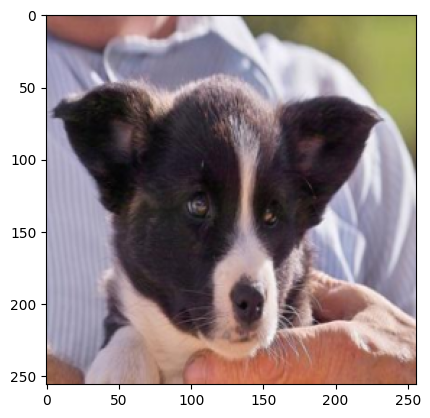

In [19]:
for data in train_loader:
  plt.imshow(data[0][0].permute(1,2,0))
  break

In [22]:
class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()
        self.conv1 = nn.Conv2d(3,32,3)
        self.act1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(32, 64, 3)
        self.act2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(2, 2)
        self.conv3 = nn.Conv2d(64, 128, 3)
        self.act3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(2, 2)
        self.flat = nn.Flatten()
        self.fc1 = nn.Linear(128*30*30, 500)
        self.fc2 = nn.Linear(500, 240)
        self.fc3 = nn.Linear(240, len(classes))
        self.softmax = nn.Softmax(dim=1)
    def forward(self, x):
        x = self.pool1(self.act1(self.conv1(x)))
        print(x.shape)
        x = self.pool2(self.act2(self.conv2(x)))
        print(x.shape)
        x = self.pool3(self.act3(self.conv3(x)))
        print(x.shape)
        x = self.flat(x)
        print(x.shape)
        x = self.fc1(x)
        print(x.shape)
        x = self.fc2(x)
        print(x.shape)
        x = self.fc3(x)
        print(x.shape)
        x = self.softmax(x)
        print(x.shape)
        print(x)
        return x

In [23]:
torch.cuda.empty_cache()

model = ConvNet().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

n_total_steps = len(train_loader)

for epoch in range(num_epochs):
    # loop = tqdm(enumerate(train_loader), total=len(train_loader))
    # print(f"Epoch: {epoch}")
    for i, (images, labels) in enumerate(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        # Forward pass
        outputs = model(images)
        # sys.exit()
        loss = criterion(outputs, labels)


        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        accuracy = (outputs.argmax(1) == labels.argmax(1)).float().mean()
        sys.exit()

        # loop.set_description(f"Epoch [{epoch}/{num_epochs}]")
        # loop.set_postfix(loss=loss.item(), acc=accuracy.item())

        # if i == len(train_loader) - 1:
        #     print (f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{n_total_steps}], Loss: {loss.item():.4f}')

print('Finished Training')

# Save the model checkpoint
torch.save(model.state_dict(), 'model.ckpt')

torch.Size([64, 32, 127, 127])
torch.Size([64, 64, 62, 62])
torch.Size([64, 128, 30, 30])
torch.Size([64, 115200])
torch.Size([64, 500])
torch.Size([64, 240])
torch.Size([64, 120])
torch.Size([64, 120])
tensor([[0.0083, 0.0084, 0.0080,  ..., 0.0080, 0.0081, 0.0089],
        [0.0083, 0.0084, 0.0079,  ..., 0.0080, 0.0081, 0.0089],
        [0.0082, 0.0084, 0.0080,  ..., 0.0079, 0.0081, 0.0089],
        ...,
        [0.0082, 0.0084, 0.0080,  ..., 0.0079, 0.0081, 0.0089],
        [0.0082, 0.0084, 0.0079,  ..., 0.0079, 0.0081, 0.0089],
        [0.0082, 0.0084, 0.0080,  ..., 0.0079, 0.0081, 0.0089]],
       grad_fn=<SoftmaxBackward0>)


SystemExit: 

In [27]:
from google.colab import files
files.download('model.ckpt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>